In [1]:
from pathlib import Path

DATASET_PATH = "./Sign Language Detection/babeczka"
root = Path(DATASET_PATH)
assert root.exists(), f"Dataset path not found: {DATASET_PATH}. Change DATASET_PATH to correct folder."
print(root)

Sign Language Detection/babeczka


In [2]:
train_images = root / "train" / "images"
train_labels = root / "train" / "labels"

test_images = root / "test" / "images"
test_labels = root / "test" / "labels"

valid_images = root / "valid" / "images"
valid_labels = root / "valid" / "labels"

print("Train images path:", train_images)
print("Train labels path:", train_labels)

Train images path: Sign Language Detection/babeczka/train/images
Train labels path: Sign Language Detection/babeczka/train/labels


In [ ]:
for p in [train_images, train_labels]:
  if not p.exists():
    print("Warning: path not found ->", p)

print("Train images:", len(list(train_images.glob("*.*"))))

Train images: 230


Showing sample: hello_2cdf95c0-7a66-11ed-a1fd-1e08bc6ed8a6_jpg.rf.922a56f4e49598a43d24e38ba503740f.jpg


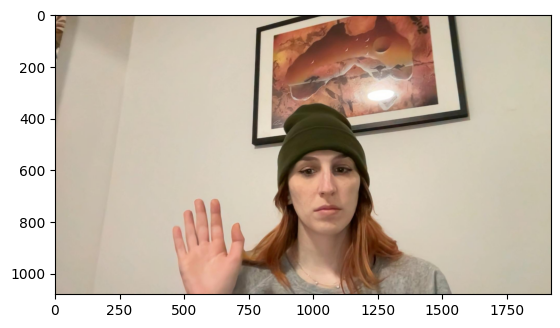

In [ ]:
import matplotlib.pyplot as plt

# show one sample (if exists)
sample_imgs = list(train_images.glob("*.*"))
if sample_imgs:
  sample_img = sample_imgs[0]
  sample_label = train_labels / (sample_img.stem + ".txt")
  print("Showing sample:", sample_img.name)
  plt.imshow(plt.imread(sample_img))
else:
  print("No images found in train/images.")

In [5]:
IMG_SIZE = 400

In [ ]:
from pathlib import Path
import yaml

data_path = root / "data.yaml"

with data_path.open("r", encoding="utf-8") as f:
  data = yaml.safe_load(f)

CLASSES = data["names"]          # list of class names
amount = data.get("nc", len(CLASSES))
print("names:", CLASSES)

names: ['hello', 'iloveyou', 'no', 'yes']


In [7]:
NUMBER_OF_CLASSES = len(CLASSES)
NUMBER_OF_CLASSES

4

In [ ]:
import cv2
import numpy as np

def crop_hand(image_path, model):
  # 1. Przygotuj obraz
  original_img = cv2.imread(image_path)
  img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
  img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0
  input_tensor = np.expand_dims(img_resized, axis=0)

  # 2. Predykcja ramki
  box = model.predict(input_tensor)[0] # [x, y, w, h] (znormalizowane)
  
  # 3. Przelicz na piksele
  h_orig, w_orig, _ = original_img.shape
  x = int(box[0] * w_orig)
  y = int(box[1] * h_orig)
  w = int(box[2] * w_orig)
  h = int(box[3] * h_orig)

  # Zabezpieczenia (żeby nie wyjść poza obraz przy błędzie modelu)
  x = max(0, x)
  y = max(0, y)
  
  # 4. Wycięcie (Crop)
  # Dodajemy mały margines (padding), żeby nie uciąć palców
  padding = 20
  crop = original_img[y-padding : y+h+padding, x-padding : x+w+padding]
  
  return crop, (x, y, w, h)

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

def load_data_from_labels(img_dir, label_dir, target_size=(IMG_SIZE, IMG_SIZE), padding=20):
  """
  Wczytuje obrazy, wycina dłonie na podstawie etykiet .txt (Ground Truth)
  i przygotowuje je do treningu klasyfikatora.
  """
  images = []
  labels = []
  
  img_files = sorted(list(img_dir.glob("*.*"))) # Szukamy jpg, png, etc.
  
  print(f"Przetwarzanie {len(img_files)} obrazów na podstawie etykiet...")

  for i, img_path in enumerate(img_files):
    # 1. Sprawdzenie czy istnieje plik etykiety
    # Szukamy pliku o tej samej nazwie w folderze labels
    label_path = label_dir / (img_path.stem + ".txt")
    
    if not label_path.exists():
      # Jeśli nie ma etykiety, nie wiemy gdzie jest dłoń -> pomijamy
      continue

    # 2. Odczytanie współrzędnych z pliku
    with open(label_path, 'r') as f:
      line = f.readline().split()
      if not line: continue
      
      # Format YOLO: class_id center_x center_y width height (znormalizowane 0-1)
      class_id = int(line[0])
      cx, cy, w_norm, h_norm = map(float, line[1:])

    # 3. Wczytanie obrazu
    img = cv2.imread(str(img_path))
    if img is None: continue
    
    # Konwersja na RGB (ważne dla treningu!)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h_img, w_img, _ = img.shape

    # 4. Przeliczenie współrzędnych (YOLO -> Piksele)
    # Obliczamy lewy górny róg
    w_px = int(w_norm * w_img)
    h_px = int(h_norm * h_img)
    x_px = int((cx * w_img) - (w_px / 2))
    y_px = int((cy * h_img) - (h_px / 2))

    # 5. Dodanie marginesu (Padding) i zabezpieczenie krawędzi
    # Chcemy wyciąć dłoń z lekkim zapasem, żeby nie uciąć palców
    x = max(0, x_px - padding)
    y = max(0, y_px - padding)
    w = min(w_img - x, w_px + 2 * padding)
    h = min(h_img - y, h_px + 2 * padding)

    # 6. Wycięcie (Crop)
    hand_crop = img[y : y + h, x : x + w]

    # Zabezpieczenie przed pustym wycinkiem (gdyby etykieta była błędna)
    if hand_crop.size == 0:
      continue

    # 7. Resize do formatu wejściowego sieci (np. 224x224)
    try:
      hand_crop_resized = cv2.resize(hand_crop, target_size)
    except Exception as e:
      print(f"Błąd resize dla {img_path.name}: {e}")
      continue

    images.append(hand_crop_resized)
    labels.append(class_id)
        
    # Pokaż postęp co 100 zdjęć
    if i % 100 == 0:
      print(f"Przetworzono {i}/{len(img_files)}")

  print(f"Zakończono. Załadowano {len(images)} poprawnych wycinków.")
  
  # Normalizacja i One-Hot Encoding
  return np.array(images) / 255.0, to_categorical(np.array(labels), num_classes=NUMBER_OF_CLASSES)

2026-01-30 22:45:51.352825: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-30 22:45:51.385664: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-30 22:46:05.265263: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [10]:
X_train, y_train = load_data_from_labels(train_images, train_labels)

Przetwarzanie 230 obrazów na podstawie etykiet...
Przetworzono 0/230
Przetworzono 100/230
Przetworzono 200/230
Zakończono. Załadowano 230 poprawnych wycinków.


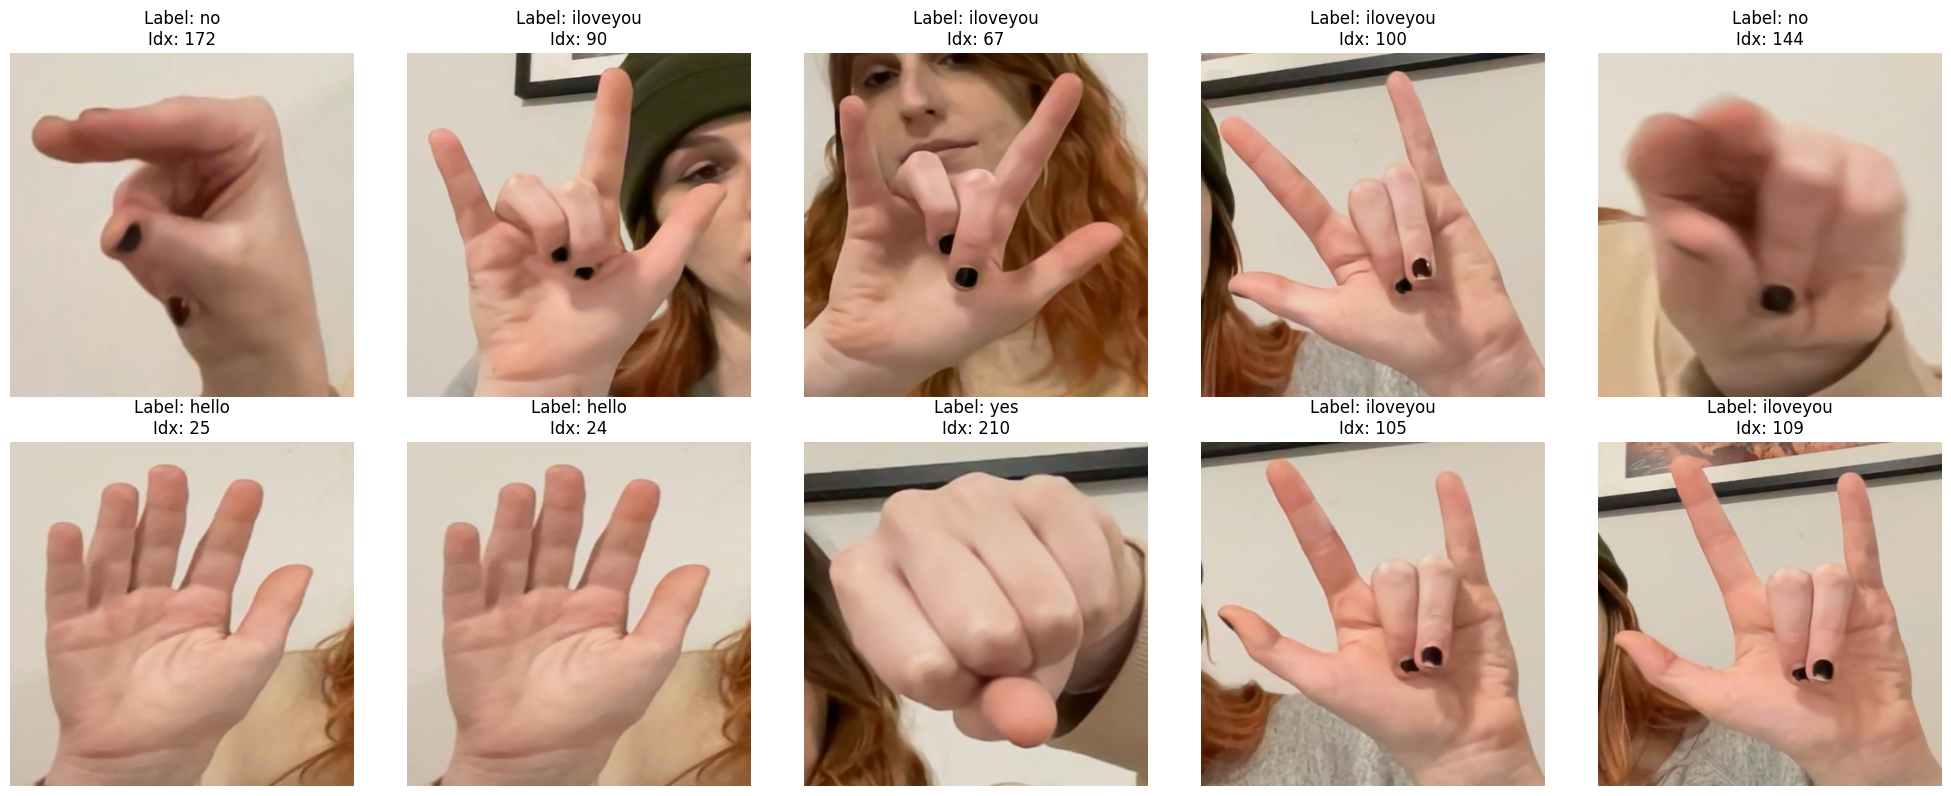

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_crops(images, labels, num_samples=10):
  plt.figure(figsize=(20, 8))
  
  # Losujemy indeksy, żeby nie oglądać tylko pierwszych zdjęć
  indices = np.random.randint(0, len(images), num_samples)
  
  for i, idx in enumerate(indices):
    # Pobieramy obraz i etykietę
    img = images[idx]
    label_onehot = labels[idx]
    
    # Dekodowanie One-Hot (np. [0, 0, 1, 0] -> 2)
    class_idx = np.argmax(label_onehot)
    class_name = CLASSES[class_idx] if class_idx < len(CLASSES) else f"Class {class_idx}"
    
    plt.subplot(2, 5, i + 1) # Układ 2 rzędy po 5 zdjęć
    plt.imshow(img)
    plt.title(f"Label: {class_name}\nIdx: {idx}")
    plt.axis('off')
      
  plt.tight_layout()
  plt.show()


visualize_crops(X_train, y_train)


In [12]:
X_train.shape

(230, 400, 400, 3)

In [13]:
X_test, y_test = load_data_from_labels(valid_images, valid_labels)

Przetwarzanie 76 obrazów na podstawie etykiet...
Przetworzono 0/76
Zakończono. Załadowano 76 poprawnych wycinków.


In [14]:
from keras import backend as K

print(K.image_data_format())

channels_last


In [ ]:
from keras import layers, models

model = models.Sequential([
  # Pierwsza warstwa splotowa - wyciąga krawędzie i proste wzory
  layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
  layers.MaxPooling2D((2, 2)),
  
  # Druga warstwa - bardziej złożone kształty dłoni
  layers.Conv2D(64, (3, 3), activation='relu'),
  layers.MaxPooling2D((2, 2)),
  
  # Trzecia warstwa
  layers.Conv2D(128, (3, 3), activation='relu'),
  layers.MaxPooling2D((2, 2)),
  
  # Spłaszczenie danych do warstw gęstych (klasyfikatora)
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dropout(0.5), # Zapobiega przeuczeniu
  layers.Dense(NUMBER_OF_CLASSES, activation='softmax') # 5 wyjść (dla każdej klasy znaku)
])

model.summary()

/mnt/d/Magisterka/Semestr 3/Uczenie Glebokie L/hand-sign-recognition/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 398, 398, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 199, 199, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 197, 197, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 98, 98, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 96, 96, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 48, 48, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 294912)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    37,748,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,842,628 (144.36 MB)

 Trainable params: 37,842,628 (144.36 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Callbacks - Zatrzymanie treningu, gdy model przestanie się uczyć
callbacks = [
  tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss'),
  tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001),
    # Zapisz model tylko, gdy wynik na walidacji się poprawi
  tf.keras.callbacks.ModelCheckpoint(
      'gesture_classifier.keras', 
      save_best_only=True, 
      monitor='val_loss'
  ),
]

In [ ]:
# Start treningu
history = model.fit(
  X_train, y_train,
  batch_size=16,
  epochs=30,
  validation_data=(X_test, y_test),
  callbacks=callbacks
)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 437ms/step - accuracy: 0.2304 - loss: 3.3905 - val_accuracy: 0.2105 - val_loss: 1.3961 - learning_rate: 0.0010
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 240ms/step - accuracy: 0.3304 - loss: 1.3410 - val_accuracy: 0.3816 - val_loss: 1.2731 - learning_rate: 0.0010
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 251ms/step - accuracy: 0.6870 - loss: 0.8708 - val_accuracy: 0.6974 - val_loss: 1.0436 - learning_rate: 0.0010
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 252ms/step - accuracy: 0.8261 - loss: 0.5534 - val_accuracy: 0.7763 - val_loss: 0.6419 - learning_rate: 0.0010
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 251ms/step - accuracy: 0.9130 - loss: 0.2684 - val_accuracy: 0.8158 - val_loss: 0.5407 - learning_rate: 0.0010
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.9870 - loss: 0.0887 - val_accuracy: 0.8553 - val_loss: 0.7525 - learning_rate: 0.0010
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 254ms/step - accuracy: 0.9652 - loss: 0.0923 - v

In [26]:
score = model.evaluate(X_test, y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8684 - loss: 0.4574 


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/stepWARNING:tensorflow:6 out of the last 8 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x78e0773b2340> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step


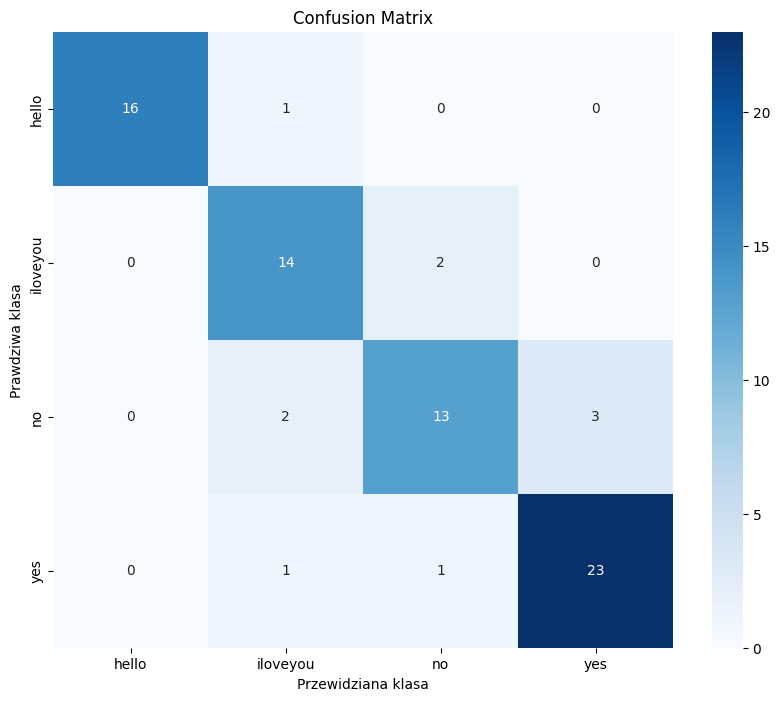

              precision    recall  f1-score   support

       hello       1.00      0.94      0.97        17
    iloveyou       0.78      0.88      0.82        16
          no       0.81      0.72      0.76        18
         yes       0.88      0.92      0.90        25

    accuracy                           0.87        76
   macro avg       0.87      0.86      0.86        76
weighted avg       0.87      0.87      0.87        76



In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. Predykcja na zbiorze testowym
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# 2. Macierz pomyłek
cm = confusion_matrix(y_true, y_pred_classes)

# 3. Wykres
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.title('Confusion Matrix')
plt.show()

# 4. Raport tekstowy
print(classification_report(y_true, y_pred_classes, target_names=CLASSES))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
Predykcja: iloveyou z pewnością 99.98%


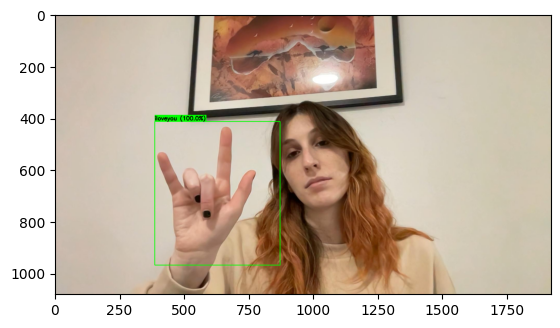

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def predict_full_pipeline(image_path, detector_model, classifier_model, classes_list):
  img_bgr = cv2.imread(image_path)
  hand_crop, coords = crop_hand(image_path, detector_model)
  x_pad = coords[0]
  y_pad = coords[1]
  w_pad = coords[2]
  h_pad = coords[3]

  # Zabezpieczenie przed pustym wycinkiem (gdyby detektor zawiódł)
  if hand_crop.size == 0:
    print("Nie udało się wyciąć dłoni (błąd detektora).")
    return

  # Preprocessing dla klasyfikatora
  img_cls = cv2.resize(hand_crop, (IMG_SIZE, IMG_SIZE)) / 255.0
  img_cls_batch = np.expand_dims(img_cls, axis=0)

  # Predykcja gestu
  predictions = classifier_model.predict(img_cls_batch, verbose=0)[0]
  class_idx = np.argmax(predictions)       # Indeks najwyższego wyniku
  confidence = predictions[class_idx]      # Pewność (0.0 - 1.0)
  
  predicted_label = classes_list[class_idx]
  
  print(f"Predykcja: {predicted_label} z pewnością {confidence*100:.2f}%")

  # wizualizacja:
  # Kolor ramki zależny od pewności (Zielony = pewny, Żółty = niepewny)
  color = (0, 255, 0) if confidence > 0.7 else (0, 255, 255)

  # Rysujemy ramkę na ORYGINALNYM obrazie BGR
  cv2.rectangle(img_bgr, (x_pad, y_pad), (x_pad + w_pad, y_pad + h_pad), color, 2)

  # Przygotowanie tekstu:
  text = f"{predicted_label} ({confidence*100:.1f}%)"
  
  # Tło pod napisem (dla czytelności)
  (text_w, text_h), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
  cv2.rectangle(img_bgr, (x_pad, y_pad - 25), (x_pad + text_w, y_pad), color, -1)
  
  # Napis
  cv2.putText(img_bgr, text, (x_pad, y_pad - 5), 
              cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)

  # Pokazanie wyniku
  cropped_img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
  plt.imshow(cropped_img_rgb)

  cv2.waitKey(0)
  cv2.destroyAllWindows()

detector = tf.keras.models.load_model('hand_detector_best.keras')
classifier = tf.keras.models.load_model('gesture_classifier.keras')

# Uruchomienie funkcji
predict_full_pipeline("Sign Language Detection/babeczka/test/images/iloveyou_1f4c00c4-7679-11ed-bb1e-1e08bc6ed8a6_jpg.rf.e6b72a4127ff5544f3bd78317ca11b0e.jpg", detector, classifier, CLASSES)